In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from DataManagement import DataViewer

In [5]:
# Clinical Data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
df_eval = pd.read_csv("./X_test/clinical_test.csv", index_col=0)

# Molecular Data
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
maf_eval = pd.read_csv("./X_test/molecular_test.csv", index_col=0)

target_df = pd.read_csv("./target_train.csv", index_col=0)

In [6]:
# columns to drop in molecular data
cols_to_drop = [
    "CHR", # the length of the chromosome is not relevant to the survival rate
    "START", # the position of the mutation is not relevant to the survival rate
    "END",
    "REF", # does not provide any information about the mutation
    "ALT", 
    "DEPTH" # it is a measure of the perf of measurement from the lab, not relevant
]

test = maf_df.drop(columns=cols_to_drop, axis=0)

In [ ]:
mol_agg = maf_df.groupby("ID").agg(
    nb_mutations=("GENE", "count"),
    mean_vaf=("VAF", "mean"),
    max_vaf=("VAF", "max"),
)

final_df = df.join(mol_agg)

,nb_mutations,mean_vaf,max_vaf
ID,,,
P100000,6,0.301300,0.7730
P100001,2,0.259500,0.4180
P100002,2,0.397000,0.5970
P100004,1,0.469100,0.4691
P100006,5,0.169300,0.3720
...,...,...,...
P132725,5,0.533600,0.8060
P132726,1,0.269000,0.2690
P132727,2,0.322250,0.3595


In [12]:
dtm = DataViewer(final_df, target_df)

In [15]:
dtm.stats_analysis()

,dtype,count_nan,nan_percentage,distinct_values,count,mean,std,min,25%,50%,75%,max
CENTER,str,0,0.000000,23,3323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM_BLAST,float64,109,3.280169,139,3214.0,5.982545,7.615439,0.0,1.0,3.0,8.0,91.0
WBC,float64,272,8.185375,699,3051.0,6.535164,10.247219,0.2,2.7,4.1,6.655,154.4
ANC,float64,193,5.808005,1026,3130.0,3.264735,5.237043,0.0,1.0,2.0,3.69,109.62
MONOCYTES,float64,601,18.086067,609,2722.0,0.955868,2.666478,0.0,0.15,0.37,0.783,44.2
HB,float64,110,3.310262,239,3213.0,9.893549,2.041158,4.0,8.5,9.7,11.2,16.6
PLT,float64,124,3.731568,586,3199.0,167.0489,149.477031,2.0,65.5,123.0,229.5,1451.0
CYTOGENETICS,str,387,11.646103,1194,2936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nb_mutations,float64,297,8.937707,16,3026.0,3.613681,2.220222,1.0,2.0,3.0,5.0,17.0
mean_vaf,float64,299,8.997893,2636,3024.0,0.30704,0.159688,0.02,0.1925,0.297,0.410775,0.989


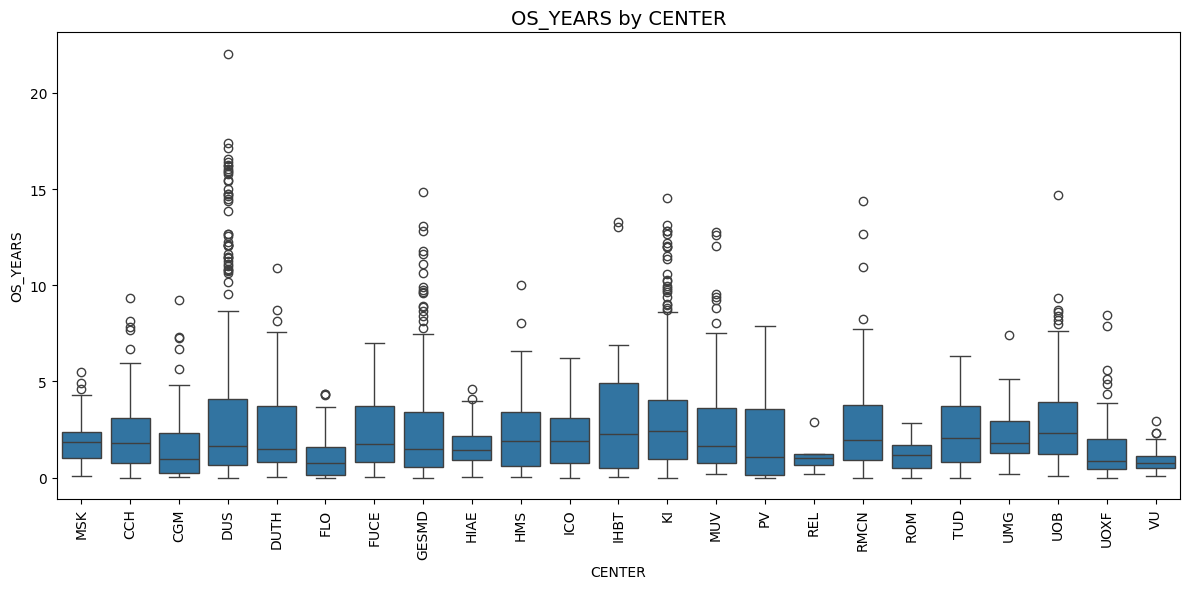

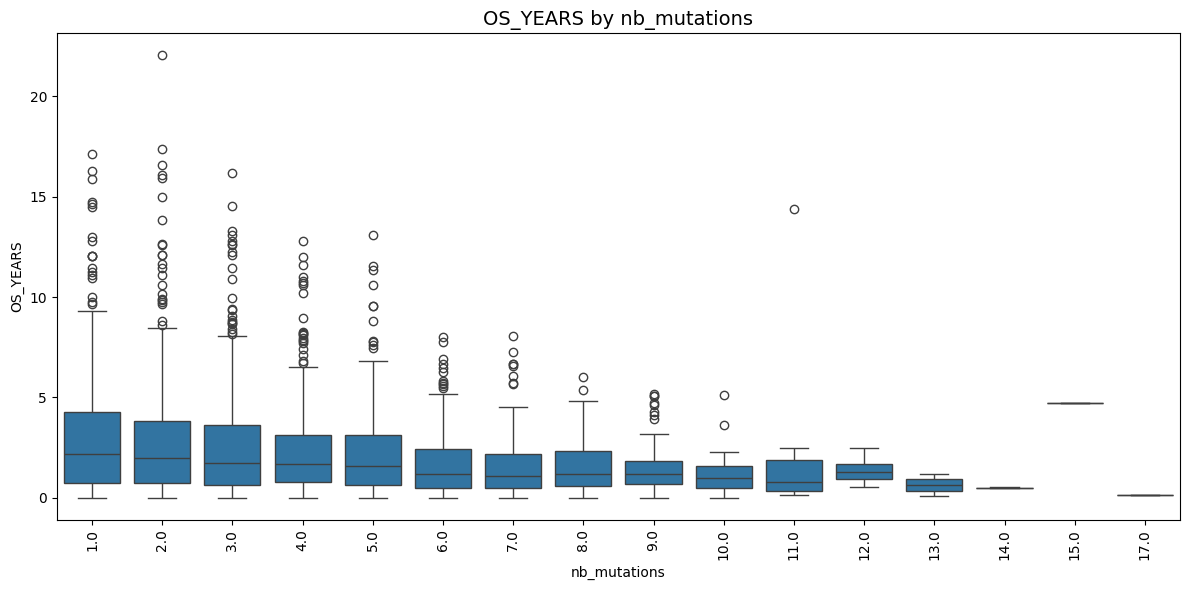

In [ ]:
dtm.plot_categorical_boxplot(["CENTER", "nb_mutations"])